# Mlp Pet Adoption


## Step 0: Mount Google Drive and Import Libraries
Download and save a copy of the Lab6 Notebook and Datasets (*test_labels.csv*) to your Google Drive, ensuring that all these files are in the same location.

In [1]:
if __name__ == '__main__':
  from google.colab import drive
  drive.mount("/content/drive")

Mounted at /content/drive


## Dataset Description

We will use a simplified version of the PetFinder [dataset](https://www.kaggle.com/c/petfinder-adoption-prediction).
There are several thousand rows in the CSV. Each row describes a pet, and each column describes an attribute.
We will use this information to predict the speed at which the pet will be adopted.

The following is a description of this dataset. Notice there are both numeric and categorical columns. There is a free text column that we will not use in this tutorial.

Column | Description| Feature Type | Data Type
------------|--------------------|----------------------|-----------------
Type | Type of animal (Dog, Cat) | Categorical | string
Age |  Age of the pet | Numerical | integer
Breed1 | Primary breed of the pet | Categorical | string
Color1 | Color 1 of pet | Categorical | string
Color2 | Color 2 of pet | Categorical | string
MaturitySize | Size at maturity | Categorical | string
FurLength | Fur length | Categorical | string
Vaccinated | Pet has been vaccinated | Categorical | string
Sterilized | Pet has been sterilized | Categorical | string
Health | Health Condition | Categorical | string
Fee | Adoption Fee | Numerical | integer
Description | Profile write-up for this pet | Text | string
PhotoAmt | Total uploaded photos for this pet | Numerical | integer
AdoptionSpeed | Speed of adoption | Classification | integer

Load required libraries.

In [83]:
import numpy as np
import pandas as pd

! pip install tensorflow==2.11.0  # comment this line for execution in your local development environment
import tensorflow as tf

from tensorflow import feature_column
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print('tensorflow version:',tf.__version__)

tensorflow version: 2.11.0


## Use Pandas to create a dataframe

[Pandas](https://pandas.pydata.org/) is a Python library with many helpful utilities for loading and working with structured data. We will use Pandas to load the dataset into a dataframe.

In [85]:
# Colab
dataframe = pd.read_csv("drive/MyDrive/lab6/petfinder-mini.csv")

# Your local development environment
# dataframe = pd.read_csv("petfinder-mini.csv")

dataframe.head()

,Unnamed: 0,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,Description,PhotoAmt,AdoptionSpeed
0,0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,Nibble is a 3+ month old ball of cuteness. He ...,1,2
1,1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,I just found it alone yesterday near my apartm...,2,0
2,2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,Their pregnant mother was dumped by her irresp...,7,3
3,3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,"Good guard dog, very alert, active, obedience ...",8,2
4,4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,This handsome yet cute boy is up for adoption....,3,2


Check dataset profile.

In [86]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770 entries, 0 to 5769
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     5770 non-null   int64 
 1   Type           5770 non-null   object
 2   Age            5770 non-null   int64 
 3   Breed1         5770 non-null   object
 4   Gender         5770 non-null   object
 5   Color1         5770 non-null   object
 6   Color2         5770 non-null   object
 7   MaturitySize   5770 non-null   object
 8   FurLength      5770 non-null   object
 9   Vaccinated     5770 non-null   object
 10  Sterilized     5770 non-null   object
 11  Health         5770 non-null   object
 12  Fee            5770 non-null   int64 
 13  Description    5765 non-null   object
 14  PhotoAmt       5770 non-null   int64 
 15  AdoptionSpeed  5770 non-null   int64 
dtypes: int64(5), object(11)
memory usage: 721.4+ KB


## Create target variable

The task in the original dataset is to predict the speed at which a pet will be adopted (e.g., in the first week, the first month, the first three months, and so on). Let's simplify this for our tutorial. Here, we will transform this into a binary classification problem, and simply predict whether the pet was adopted or not.

After modifying the label column, 0 will indicate the pet was not adopted, and 1 will indicate it was.

In [87]:
# In the original dataset "4" indicates the pet was not adopted.
dataframe['target'] = np.where(dataframe['AdoptionSpeed']==4, 0, 1)

# Drop un-used columns.
dataframe = dataframe.drop(columns=['AdoptionSpeed', 'Description'])

In [88]:
dataframe.head(20)

,Unnamed: 0,Type,Age,Breed1,Gender,Color1,Color2,MaturitySize,FurLength,Vaccinated,Sterilized,Health,Fee,PhotoAmt,target
0,0,Cat,3,Tabby,Male,Black,White,Small,Short,No,No,Healthy,100,1,1
1,1,Cat,1,Domestic Medium Hair,Male,Black,Brown,Medium,Medium,Not Sure,Not Sure,Healthy,0,2,1
2,2,Dog,1,Mixed Breed,Male,Brown,White,Medium,Medium,Yes,No,Healthy,0,7,1
3,3,Dog,4,Mixed Breed,Female,Black,Brown,Medium,Short,Yes,No,Healthy,150,8,1
4,4,Dog,1,Mixed Breed,Male,Black,No Color,Medium,Short,No,No,Healthy,0,3,1
5,5,Cat,3,Domestic Short Hair,Female,Cream,Gray,Medium,Short,No,No,Healthy,0,2,1
6,6,Cat,12,Domestic Long Hair,Male,Black,No Color,Medium,Long,No,Not Sure,Healthy,300,3,1
7,7,Cat,2,Domestic Medium Hair,Female,Gray,No Color,Medium,Medium,No,No,Healthy,0,6,1
8,8,Cat,12,Domestic Medium Hair,Female,Black,White,Medium,Medium,Not Sure,Not Sure,Healthy,0,2,0
9,9,Dog,2,Mixed Breed,Male,Black,Brown,Medium,Short,No,No,Healthy,0,7,1


## Step 1: Dataset Splitting and Preprocessing

We will randomly shuffle and then split the dataset into the training set `train`, validation set `val`, and testing set `test`. We will wrap the Dataframes with [tf.data](https://www.tensorflow.org/guide/datasets). This will enable us to use feature columns as a bridge to map from the columns in the Pandas Dataframe to features used to train the model.

**Task**: Implement the function `df_to_dataset()`.

Input:
- `dataframe`: A Pandas Dataframe containing the data, including a 'target' column.
- `shuffle`: A boolean indicating whether to shuffle the dataset (default is True).
- `batch_size`: An integer specifying the number of samples per batch (default is 32).

Output:
- A `tf.data.Dataset` object containing the features and labels, optionally shuffled and batched.

In [89]:
train, test = train_test_split(dataframe, test_size=0.2)
train, val = train_test_split(train, test_size=0.2)
print('Train examples: ', len(train))
print('Validation examples: ', len(val))
print('Test examples: ',  len(test), )


# A utility method to create a tf.data dataset from a Pandas Dataframe
def df_to_dataset(dataframe, shuffle=True, batch_size=32):
    # TODO: Your code for Task 1 here
    # Use soft copy to maintain the original dataframe (hint: use library function `copy` of dataframe rather than '=' assignment)
    df_copy = dataframe.copy()

    # Remove the 'target' column from the dataframe and store it in 'labels' (hint: use library function `dataframe.pop()`)
    labels = df_copy.pop('target')

    # Create a TensorFlow dataset from the dataframe and labels (hint: use library function `tf.data.Dataset.from_tensor_slices()`, please refer to https://www.tensorflow.org/api_docs/python/tf/data/Dataset)
    ds = tf.data.Dataset.from_tensor_slices((dict(df_copy), labels))

    # Shuffle the dataset if 'shuffle' is set to True (hint: the library function `shuffle` is a method of your TensorFlow dataset; please specify the random seed as 20241109 to obtain the same data shuffle result among multiple executions of this codeblock)
    if shuffle:
      ds = ds.shuffle(len(dataframe),seed=20241109)

    # Batch the dataset with the specified batch size (hint: the library function `batch` is a method of your TensorFlow dataset)
    ds = ds.batch(batch_size)

    # Return the prepared TensorFlow dataset
    return ds


batch_size = 5
train_ds = df_to_dataset(train, batch_size=batch_size)
val_ds = df_to_dataset(val, shuffle=False, batch_size=batch_size)
test_ds = df_to_dataset(test, shuffle=False, batch_size=batch_size)

Train examples:  3692
Validation examples:  924
Test examples:  1154


## Understand the input pipeline

Now that we have created the input pipeline, let's call it to see the format of the data it returns. We have used a small batch size to keep the output readable. Notably, if you did not specify the random seed when calling the dataset shuffle function, you will observe different outputs per run.

In [90]:
for feature_batch, label_batch in train_ds.take(1):
    print('Every feature:', list(feature_batch.keys()))
    print('A batch of ages:', feature_batch['Age'])
    print('A batch of targets:', label_batch)

Every feature: ['Unnamed: 0', 'Type', 'Age', 'Breed1', 'Gender', 'Color1', 'Color2', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health', 'Fee', 'PhotoAmt']
A batch of ages: tf.Tensor([16 24 14 12 60], shape=(5,), dtype=int64)
A batch of targets: tf.Tensor([1 0 1 1 1], shape=(5,), dtype=int64)


## Feature engineering (out of scope)
TensorFlow provides many types of feature columns. In this section, we will create several types of feature columns and demonstrate how they transform a column from the dataframe. This part is out of the scope of this project. You may take a quick look at the content if you would like to.

In [91]:
# We will use this batch to demonstrate several types of feature columns
example_batch = next(iter(train_ds))[0]

# A utility method to create a feature column
# and to transform a batch of data
def demo(feature_column):
    feature_layer = layers.DenseFeatures(feature_column)
    print(feature_layer(example_batch).numpy())


photo_count = feature_column.numeric_column('PhotoAmt')
demo(photo_count)


age = feature_column.numeric_column('Age')
age_buckets = feature_column.bucketized_column(age, boundaries=[1, 3, 5])
demo(age_buckets)


animal_type = feature_column.categorical_column_with_vocabulary_list('Type', ['Cat', 'Dog'])

animal_type_one_hot = feature_column.indicator_column(animal_type)
demo(animal_type_one_hot)


# Notice the input to the embedding column is the categorical column
# we previously created
breed1 = feature_column.categorical_column_with_vocabulary_list('Breed1', dataframe.Breed1.unique())
breed1_embedding = feature_column.embedding_column(breed1, dimension=8)
demo(breed1_embedding)



breed1_hashed = feature_column.categorical_column_with_hash_bucket('Breed1', hash_bucket_size=10)
demo(feature_column.indicator_column(breed1_hashed))


crossed_feature = feature_column.crossed_column([age_buckets, animal_type], hash_bucket_size=10)
demo(feature_column.indicator_column(crossed_feature))

[[3.]
 [2.]
 [6.]
 [3.]
 [2.]]
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]
[[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]
[[ 0.33679765  0.3314117  -0.50388753 -0.37313554  0.17984104 -0.3976653
   0.34302157  0.32506824]
 [ 0.4367843  -0.0720726   0.04847346  0.14922644  0.10087743  0.42197192
  -0.20479774  0.13908271]
 [ 0.2828817   0.46866733 -0.2989331   0.35812002 -0.13487776 -0.03703599
   0.12381221  0.06144594]
 [ 0.16069397  0.04513988  0.447208    0.16665481  0.6440117   0.11411331
   0.26159146 -0.19615477]
 [ 0.33679765  0.3314117  -0.50388753 -0.37313554  0.17984104 -0.3976653
   0.34302157  0.32506824]]
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


## Choose which columns to use
We have seen how to use several types of feature columns. Now we will use them to train a model. The goal of this tutorial is to show you the complete code (e.g. mechanics) needed to work with feature columns. We have selected a few columns to train our model below, arbitrarily.

Key point: If your aim is to build an accurate model, try a larger dataset of your own, and think carefully about which features are the most meaningful to include, and how they should be represented.

In [92]:
feature_columns = []

# numeric cols
for header in ['PhotoAmt', 'Fee', 'Age']:
    feature_columns.append(feature_column.numeric_column(header))

# bucketized cols
age = feature_column.numeric_column('Age')
age_buckets = feature_column.bucketized_column(age, boundaries=[1, 2, 3, 4, 5])
feature_columns.append(age_buckets)

# indicator_columns
indicator_column_names = ['Type', 'Color1', 'Color2', 'Gender', 'MaturitySize', 'FurLength', 'Vaccinated', 'Sterilized', 'Health']
for col_name in indicator_column_names:
    categorical_column = feature_column.categorical_column_with_vocabulary_list(col_name, dataframe[col_name].unique())
    indicator_column = feature_column.indicator_column(categorical_column)
    feature_columns.append(indicator_column)

# embedding columns
breed1 = feature_column.categorical_column_with_vocabulary_list('Breed1', dataframe.Breed1.unique())
breed1_embedding = feature_column.embedding_column(breed1, dimension=8)
feature_columns.append(breed1_embedding)

# crossed columns
age_type_feature = feature_column.crossed_column([age_buckets, animal_type], hash_bucket_size=100)
feature_columns.append(feature_column.indicator_column(age_type_feature))

## Create a feature layer
Now that we have defined our feature columns, we will use a [DenseFeatures](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/layers/DenseFeatures) layer to input them into our Keras model.

In [93]:
feature_layer = tf.keras.layers.DenseFeatures(feature_columns)

Earlier, we used a small batch size to demonstrate how feature columns worked. We will create a new input pipeline with a larger batch size.

In [94]:
# You may customize the batch_size by yourself, as part of hyperparameter tuning
batch_size = 128

train_ds = df_to_dataset(train, batch_size=batch_size)
val_ds = df_to_dataset(val, shuffle=False, batch_size=batch_size)
test_ds = df_to_dataset(test, shuffle=False, batch_size=batch_size)

## Step 2: MLP Model Building, Compiling, and Training

**Task 2.1**: Implement an MLP model according to the following rules:
- Right after the `feature_layer`, there are two hidden `Dense` layers followed by a `Dropout` operator.
- The activation for hidden `Dense` layer should be `ReLU`.
- The output `Dense` layer should be designed for our `binary classification` task.

The function should return the built model. Please note that you do not need to call `model.compile()` or `model.fit()` in this function because they are follow-up tasks.

In [95]:
# Function for MLP model initialization
def get_model():
    # TODO: Your code for Task 2.1 here
    model = tf.keras.Sequential([
        feature_layer,
        # The first Dense layer
        layers.Dense(128, activation='relu'),

        # The second Dense layer
        layers.Dense(128, activation='relu'),

        # The Dropout operator, you may assign the dropout rate with 0.1
        layers.Dropout(0.1),

        # The output layer
        layers.Dense(1, activation='sigmoid')

    ])
    # return the initialized model
    return model

model = get_model()

**Task 2.2**: Implement the compile method for an MLP according to the following rules:
- Use `Adam` optimizer with a configurable parameter `learning_rate`.
- The loss function should be one of the `Binary Loss` family.
- Employ `accuracy` as a validation metric.

**Task 2.3**: Implement the training method for an MLP.

In [96]:
# Function for MLP model compiling
def compile_model(model):
    # TODO: Your code for Task 2.2 here
    model.compile(
        # optimizer
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

        # loss function
        loss=tf.keras.losses.BinaryCrossentropy(),

        # metrics specification
        metrics=['accuracy']

    )
    # return the compiled model
    return model

# We use the side effect of your function
model = compile_model(model)


# MLP training
train_history = model.fit(
    # TODO: Your code for Task 2.3 here
    # training data
    train_ds,

    # validation data
    validation_data=val_ds,

    # epoch configuration
    epochs=30

)

Epoch 1/30


29/29 [==============================] - ETA: 0s - loss: 0.7002 - accuracy: 0.6934

29/29 [==============================] - 4s 45ms/step - loss: 0.7002 - accuracy: 0.6934 - val_loss: 0.5653 - val_accuracy: 0.7511
Epoch 2/30
29/29 [==============================] - 0s 9ms/step - loss: 0.6776 - accuracy: 0.7053 - val_loss: 0.6572 - val_accuracy: 0.7056
Epoch 3/30
29/29 [==============================] - 0s 9ms/step - loss: 0.6209 - accuracy: 0.7031 - val_loss: 0.5762 - val_accuracy: 0.7587
Epoch 4/30
29/29 [==============================] - 0s 8ms/step - loss: 0.6124 - accuracy: 0.7069 - val_loss: 0.5595 - val_accuracy: 0.7522
Epoch 5/30
29/29 [==============================] - 0s 9ms/step - loss: 0.5789 - accuracy: 0.7102 - val_loss: 0.5541 - val_accuracy: 0.7587
Epoch 6/30
29/29 [==============================] - 0s 8ms/step - loss: 0.5538 - accuracy: 0.7186 - val_loss: 0.5303 - val_accuracy: 0.7597
Epoch 7/30
29/29 [==============================] - 0s 8ms/step - loss: 0.5457 - accuracy: 0.7275 - val_loss: 0.5236 - val_accuracy: 0.7608
Epoch 8/30
29/29 [============

In [97]:
loss, accuracy = model.evaluate(test_ds)
print("Accuracy", accuracy)

10/10 [==============================] - 0s 4ms/step - loss: 0.5877 - accuracy: 0.7565
Accuracy 0.7564991116523743


In [98]:
def visualize_training(history, lw = 3):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,10))
    plt.subplot(2,1,1)
    plt.plot(history.history['accuracy'], label = 'training', marker = '*', linewidth = lw)
    plt.plot(history.history['val_accuracy'], label = 'validation', marker = 'o', linewidth = lw)
    plt.title('Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend(fontsize = 'x-large')


    plt.subplot(2,1,2)
    plt.plot(history.history['loss'], label = 'training', marker = '*', linewidth = lw)
    plt.plot(history.history['val_loss'], label = 'validation', marker = 'o', linewidth = lw)
    plt.title('Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(fontsize = 'x-large')
    plt.grid(True)
    plt.show()

#     plt.figure(figsize=(10,5))
#     plt.plot(history.history['lr'], label = 'lr', marker = '*',linewidth = lw)
#     plt.title('Learning Rate')
#     plt.xlabel('Epochs')
#     plt.ylabel('Learning Rate')
#     plt.grid(True)
#     plt.show()

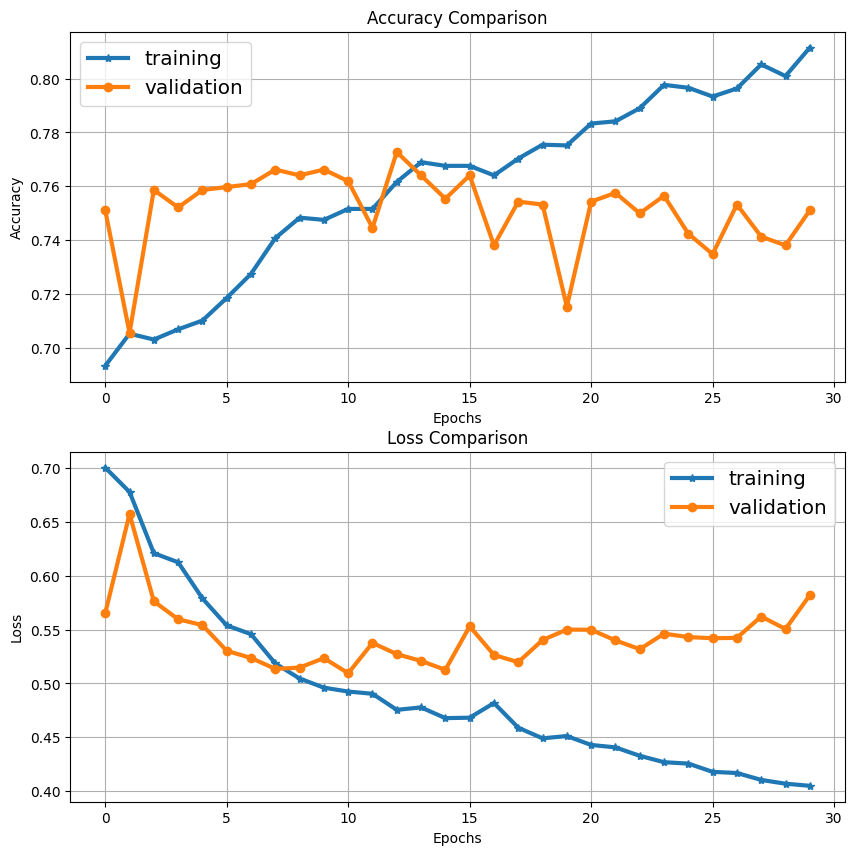

In [99]:
visualize_training(train_history)

You may save the model by running the following code.

In [100]:
model.save_weights("mlp_model.weights.h5")
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_features_39 (DenseFea  multiple                 1144      
 tures)                                                          
                                                                 
 dense_18 (Dense)            multiple                  19328     
                                                                 
 dense_19 (Dense)            multiple                  16512     
                                                                 
 dropout_6 (Dropout)         multiple                  0         
                                                                 
 dense_20 (Dense)            multiple                  129       
                                                                 
Total params: 37,113
Trainable params: 37,113
Non-trainable params: 0
__________________________________________________

You may load the model you just saved and check the accuracy again.

In [102]:
mlp_model = get_model()
mlp_model = compile_model(mlp_model)
mlp_model.evaluate(test_ds)

mlp_model.load_weights("mlp_model.weights.h5")

loss, accuracy = mlp_model.evaluate(test_ds)
print("Accuracy", accuracy)

10/10 [==============================] - 0s 4ms/step - loss: 0.5877 - accuracy: 0.7565
Accuracy 0.7564991116523743


# Export model

Export your notebook and save the `mlp_model.weights.h5` model weight file.

![image](assets/export_py.jpeg)